In [1]:
import os
import sys
import argparse

import seaborn as sns
import matplotlib.pyplot as plt

from data import *
from utils import *
from scipy import stats
from datetime import datetime

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Attack'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig
from BA import oh_binary_accuracy
from WB import *

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=5_000, help='Total # of samples') # 2_000 -> 5_000
parser.add_argument('--mb_size', type=int, default=32, help='Mini-batch size. See utils.py') # 64 -> 32; maybe 48?
parser.add_argument('--h_dim', type=int, default=48, help='Dim of latent vector') # 48 -> 64; maybe 64
parser.add_argument('--capacity', type=int, default=48, help='Capacity of network. See utils.py')

parser.add_argument('--x_fdim', type=int, default=256, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=256, help='Input y_fdim. See utils.py')
parser.add_argument('--z_fdim', type=int, default=64, help='Input z_fdim. See utils.py')

parser.add_argument('--c_accu', type=float, default=50, help='Input weight on recons_error')
parser.add_argument('--start_iter', type=int, default=0, help='Input start_iter for training')

parser.add_argument('--lr', type=float, default=7e-05, help='Input learning rate for optimizer') # 1e-4 -> 7e-5 -> 5e-5
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off') # 100 -> 300 -> 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

h_dim = opt.h_dim

## Loading Dataset etc.

In [3]:
_, xtest, ipVec_dim, nChannels = get_mmcelebahq_dataloader(args=opt)

info 0 5000 1


/Users/arthurclarysse/Desktop/🎓/03 Masterproef CS/VUB-MT-Development/Models/GenRKM-MMCelebHQ-V3/data.py:31: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/aten/src/ATen/native/TensorShape.cpp:4483.)
  label = torch.tensor(label, dtype=torch.double).T


info 5001 10001 1


In [4]:
vta = [False, True]
model = '3V'            # 1V, 2V-IS, 2V-IL, 3V
max_batches = 32
i_val = 10
epsilon = 0.2

In [5]:
def kPCA(X, Y, Z, nviews=3, eps=1e-6):
    if nviews == 3:
        a = (X @ X.T + Y @ Y.T + Z @ Z.T) / nviews
    elif nviews == 2:
        a = (X @ X.T + Y @ Y.T) / nviews
    else:
        a = (X @ X.T) / nviews

    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)

    return h, s

## Loading The Model

In [6]:
model_1V = torch.load('./out/Final-1V.tar', weights_only=False)
model_2V_IS = torch.load('./out/Final-2V-IS.tar', weights_only=False)
model_2V_IL = torch.load('./out/Final-2V-IL.tar', weights_only=False)
model_3V = torch.load('./out/Final.tar', weights_only=False)

In [7]:
# Single View Networks
net_im_en_1V = model_1V['net_im_en']
net_im_de_1V = model_1V['net_im_de']

# Two View Networks - Image + Sketch
net_im_en_2V_IS = model_2V_IS['net_im_en']
net_sk_en_2V_IS = model_2V_IS['net_sk_en']

net_im_de_2V_IS = model_2V_IS['net_im_de']
net_sk_de_2V_IS = model_2V_IS['net_sk_de']

# Two View Networks - Image + Label
net_im_en_2V_IL = model_2V_IL['net_im_en']
net_la_en_2V_IL = model_2V_IL['net_la_en']

net_im_de_2V_IL = model_2V_IL['net_im_de']
net_la_de_2V_IL = model_2V_IL['net_la_de']

# Three View Networks - Image + Sketch + Label
net_im_en_3V = model_3V['net_im_en']
net_sk_en_3V = model_3V['net_sk_en']
net_la_en_3V = model_3V['net_la_en']

net_im_de_3V = model_3V['net_im_de']
net_sk_de_3V = model_3V['net_sk_de']
net_la_de_3V = model_3V['net_la_de']

## Attack

In [8]:
net_im_en_1V.eval()
net_im_en_2V_IS.eval()
net_sk_en_2V_IS.eval()
net_im_en_2V_IL.eval()
net_la_en_2V_IL.eval()
net_im_en_3V.eval()
net_sk_en_3V.eval()
net_la_en_3V.eval()

net_im_de_1V.eval()
net_im_de_2V_IS.eval()
net_sk_de_2V_IS.eval()
net_im_de_2V_IL.eval()
net_la_de_2V_IL.eval()
net_im_de_3V.eval()
net_sk_de_3V.eval()
net_la_de_3V.eval()

NetLaDe(
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (skip): Linear(in_features=128, out_features=256, bias=True)
  (drop1): Dropout(p=0.1, inplace=False)
  (drop2): Dropout(p=0.1, inplace=False)
  (out): Linear(in_features=256, out_features=40, bias=True)
)

In [9]:
all_data_im, all_data_sk, all_data_la = [], [], []

im_en_1V = []
im_en_2V_IS, sk_en_2V_IS = [], []
im_en_2V_IL, la_en_2V_IL = [], []
im_en_3V, sk_en_3V, la_en_3V = [], [], []

im_de_1V = []
im_de_2V_IS, sk_de_2V_IS = [], []
im_de_2V_IL, la_de_2V_IL = [], []
im_de_3V, sk_de_3V, la_de_3V = [], [], []

im_loss_1V = []
im_loss_2V_IS, sk_loss_2V_IS, loss_2V_IS = [], [], []
im_loss_2V_IL, la_loss_2V_IL, loss_2V_IL = [], [], []
im_loss_3V, sk_loss_3V, la_loss_3V, loss_3V = [], [], [], []

In [10]:
recon_loss1 = torch.nn.MSELoss()
recon_loss2 = torch.nn.MSELoss()
recon_loss3 = torch.nn.BCEWithLogitsLoss()

In [11]:
FGSM_3V_I = WB_Attack(net_in1=net_im_en_3V, net_out1=net_im_de_3V, net_in2=net_sk_en_3V, net_out2=net_sk_de_3V, net_in3=net_la_en_3V, net_out3=net_la_de_3V, kPCA=kPCA, opt=opt, vta=[True, False])
FGSM_3V_S = WB_Attack(net_in1=net_im_en_3V, net_out1=net_im_de_3V, net_in2=net_sk_en_3V, net_out2=net_sk_de_3V, net_in3=net_la_en_3V, net_out3=net_la_de_3V, kPCA=kPCA, opt=opt, vta=[False, True])
FGSM_3V_IS = WB_Attack(net_in1=net_im_en_3V, net_out1=net_im_de_3V, net_in2=net_sk_en_3V, net_out2=net_sk_de_3V, net_in3=net_la_en_3V, net_out3=net_la_de_3V, kPCA=kPCA, opt=opt, vta=[True, True])

FGSM_2V_IS_I = WB_Attack(net_in1=net_im_en_2V_IS, net_out1=net_im_de_2V_IS, net_in2=net_sk_en_2V_IS, net_out2=net_sk_de_2V_IS, net_in3=None, net_out3=None, kPCA=kPCA, opt=opt, vta=[True, False])
FGSM_2V_IS_S = WB_Attack(net_in1=net_im_en_2V_IS, net_out1=net_im_de_2V_IS, net_in2=net_sk_en_2V_IS, net_out2=net_sk_de_2V_IS, net_in3=None, net_out3=None, kPCA=kPCA, opt=opt, vta=[False, True])
FGSM_2V_IS_IS = WB_Attack(net_in1=net_im_en_2V_IS, net_out1=net_im_de_2V_IS, net_in2=net_sk_en_2V_IS, net_out2=net_sk_de_2V_IS, net_in3=None, net_out3=None, kPCA=kPCA, opt=opt, vta=[True, True])

FGSM_2V_IL_I = WB_Attack(net_in1=net_im_en_2V_IL, net_out1=net_im_de_2V_IL, net_in2=None, net_out2=None, net_in3=net_la_en_2V_IL, net_out3=net_la_de_2V_IL, kPCA=kPCA, opt=opt, vta=[True, False])
FGSM_1V_I = WB_Attack(net_in1=net_im_en_1V, net_out1=net_im_de_1V, net_in2=None, net_out2=None, net_in3=None, net_out3=None, kPCA=kPCA, opt=opt, vta=[True, False])

In [12]:
if model == '3V':
    if vta[0] and vta[1]:
        attack = FGSM_3V_IS
    elif vta[0] and not vta[1]:
        attack = FGSM_3V_I
    elif not vta[0] and vta[1]:
        attack = FGSM_3V_S
    else:
        raise ValueError('Invalid VTA choice. Choose from [T, T], [T, F], or [F, T].')

elif model == '2V-IS':
    if vta[0] and vta[1]:
        attack = FGSM_2V_IS_IS
    elif vta[0] and not vta[1]:
        attack = FGSM_2V_IS_I
    elif not vta[0] and vta[1]:
        attack = FGSM_2V_IS_S
    else:
        raise ValueError('Invalid VTA choice. Choose from [T, T] or [T, F].')

elif model == '2V-IL':
    attack = FGSM_2V_IL_I

elif model == '1V':
    attack = FGSM_1V_I
    
else:
    raise ValueError('Invalid model choice. Choose from: 1V, 2V-IS, 2V-IL, 3V.')

In [13]:
adv_images, adv_sketches = [], []

In [14]:
for i, (data_im, data_sk, data_la) in enumerate(xtest):
    if i >= max_batches:
        break

    if vta[0] and vta[1]:
        adv_batch_fgsm_I, adv_batch_fgsm_S, _, _ = attack.create_adversarial_batch_fgsm(data_im, data_sk, data_la, epsilon=epsilon)
        print(f'   > FGSM adversarial batch created.')

    elif vta[0] and not vta[1]:
        adv_batch_fgsm_I, _ = attack.create_adversarial_batch_fgsm(data_im, data_sk, data_la, epsilon=epsilon)
        print(f'   > FGSM adversarial batch created.')

    elif not vta[0] and vta[1]:
        adv_batch_fgsm_S, _ = attack.create_adversarial_batch_fgsm(data_im, data_sk, data_la, epsilon=epsilon)
        print(f'   > FGSM adversarial batch created.')

    else:
        adv_batch_fgsm_I, _ = attack.create_adversarial_batch_fgsm(data_im, data_sk, data_la, epsilon=epsilon)
        print(f'   > FGSM adversarial batch created.')

    adv_images.append(adv_batch_fgsm_I.cpu() if vta[0] else data_im.cpu())
    adv_sketches.append(adv_batch_fgsm_S.cpu() if vta[1] else data_sk.cpu())

   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
   > FGSM adversarial batch created.
 

In [15]:
all_im, all_sk, all_la = [], [], []
all_adv_im, all_adv_sk = [], []

im_en_1V = []
im_en_2V_IS, sk_en_2V_IS = [], []
im_en_2V_IL, la_en_2V_IL = [], []
im_en_3V, sk_en_3V, la_en_3V = [], [], []

adv_im_en_1V = []
adv_im_en_2V_IS, adv_sk_en_2V_IS = [], []
adv_im_en_2V_IL, adv_la_en_2V_IL = [], []
adv_im_en_3V, adv_sk_en_3V, adv_la_en_3V = [], [], []

im_de_1V = []
im_de_2V_IS, sk_de_2V_IS = [], []
im_de_2V_IL, la_de_2V_IL = [], []
im_de_3V, sk_de_3V, la_de_3V = [], [], []

U_1Vs = []
U_2V_ISs, V_2V_ISs = [], []
U_2V_TSs, W_2V_TSs = [], []
U_3Vs, V_3Vs, W_3Vs = [], [], []

adv_im_de_1V = []
adv_im_de_2V_IS, adv_sk_de_2V_IS = [], []
adv_im_de_2V_IL, adv_la_de_2V_IL = [], []
adv_im_de_3V, adv_sk_de_3V, adv_la_de_3V = [], [], []

In [16]:
xtest_iter = iter(xtest)

for i in range(max_batches):
    im, sk, la = next(xtest_iter)

    adv_im = adv_images[i]
    adv_sk = adv_sketches[i]

    all_im.append(im.cpu())
    all_sk.append(sk.cpu())
    all_la.append(la.cpu())
    all_adv_im.append(adv_im.cpu())
    all_adv_sk.append(adv_sk.cpu())

    # Encode original and adversarial batches
    with torch.no_grad():
        # 1 View - Clean
        im_en_1V.append(net_im_en_1V(im.cpu()))

        # 2 View IS - Clean
        im_en_2V_IS.append(net_im_en_2V_IS(im.cpu()))
        sk_en_2V_IS.append(net_sk_en_2V_IS(sk.cpu()))

        # 2 View IL - Clean
        im_en_2V_IL.append(net_im_en_2V_IL(im.cpu()))
        la_en_2V_IL.append(net_la_en_2V_IL(la.cpu()))

        # 3 View - Clean
        im_en_3V.append(net_im_en_3V(im.cpu()))
        sk_en_3V.append(net_sk_en_3V(sk.cpu()))
        la_en_3V.append(net_la_en_3V(la.cpu()))

        # 1 View - Adversarial
        adv_im_en_1V.append(net_im_en_1V(adv_im.cpu()))

        # 2 View IS - Adversarial
        adv_im_en_2V_IS.append(net_im_en_2V_IS(adv_im.cpu()))
        adv_sk_en_2V_IS.append(net_sk_en_2V_IS(adv_sk.cpu()))

        # 2 View IL - Adversarial
        adv_im_en_2V_IL.append(net_im_en_2V_IL(adv_im.cpu()))
        adv_la_en_2V_IL.append(net_la_en_2V_IL(la.cpu()))

        adv_im_en_3V.append(net_im_en_3V(adv_im))
        adv_sk_en_3V.append(net_sk_en_3V(adv_sk.cpu()))
        adv_la_en_3V.append(net_la_en_3V(la.cpu()))

In [17]:
all_im = torch.cat(all_im, dim=0)
all_sk = torch.cat(all_sk, dim=0)
all_la = torch.cat(all_la, dim=0)
all_adv_im = torch.cat(all_adv_im, dim=0)
all_adv_sk = torch.cat(all_adv_sk, dim=0)

im_en_1V = torch.cat(im_en_1V, dim=0)
im_en_2V_IS = torch.cat(im_en_2V_IS, dim=0)
sk_en_2V_IS = torch.cat(sk_en_2V_IS, dim=0)
im_en_2V_IL = torch.cat(im_en_2V_IL, dim=0)
la_en_2V_IL = torch.cat(la_en_2V_IL, dim=0)
im_en_3V = torch.cat(im_en_3V, dim=0)
sk_en_3V = torch.cat(sk_en_3V, dim=0)
la_en_3V = torch.cat(la_en_3V, dim=0)   

adv_im_en_1V = torch.cat(adv_im_en_1V, dim=0)
adv_im_en_2V_IS = torch.cat(adv_im_en_2V_IS, dim=0)
adv_sk_en_2V_IS = torch.cat(adv_sk_en_2V_IS, dim=0)
adv_im_en_2V_IL = torch.cat(adv_im_en_2V_IL, dim=0)
adv_la_en_2V_IL = torch.cat(adv_la_en_2V_IL, dim=0)
adv_im_en_3V = torch.cat(adv_im_en_3V, dim=0)
adv_sk_en_3V = torch.cat(adv_sk_en_3V, dim=0)
adv_la_en_3V = torch.cat(adv_la_en_3V, dim=0)

In [18]:
with torch.no_grad():
    for i in range(i_val):
        start, stop = i * 100, (i + 1) * 100

        #! Calculate latent respresentations
        h_1V, _ = kPCA(im_en_1V[start:stop], None, None, nviews=1)
        h_2V_IS, _ = kPCA(im_en_2V_IS[start:stop], sk_en_2V_IS[start:stop], None, nviews=2)
        h_2V_IL, _ = kPCA(im_en_2V_IL[start:stop], la_en_2V_IL[start:stop], None, nviews=2)
        h_3V, _ = kPCA(im_en_3V[start:stop], sk_en_3V[start:stop], la_en_3V[start:stop], nviews=3)

        adv_h_1V, _ = kPCA(adv_im_en_1V[start:stop], None, None, nviews=1)
        adv_h_2V_IS, _ = kPCA(adv_im_en_2V_IS[start:stop], adv_sk_en_2V_IS[start:stop], None, nviews=2)
        adv_h_2V_IL, _ = kPCA(adv_im_en_2V_IL[start:stop], adv_la_en_2V_IL[start:stop], None, nviews=2)
        adv_h_3V, _ = kPCA(adv_im_en_3V[start:stop], adv_sk_en_3V[start:stop], adv_la_en_3V[start:stop], nviews=3)

        #! Calculate interconnection matrices
        U_1V = im_en_1V[start:stop].T @ h_1V
        U_2V_IS = im_en_2V_IS[start:stop].T @ h_2V_IS
        U_2V_IL = im_en_2V_IL[start:stop].T @ h_2V_IL
        U_3V = im_en_3V[start:stop].T @ h_3V

        V_2V_IS = sk_en_2V_IS[start:stop].T @ h_2V_IS
        V_3V = sk_en_3V[start:stop].T @ h_3V

        W_2V_IL = la_en_2V_IL[start:stop].T @ h_2V_IL
        W_3V = la_en_3V[start:stop].T @ h_3V

        # U_1Vs.append(U_1V.cpu())
        # U_2V_ISs.append(U_2V_IS.cpu())
        # V_2V_ISs.append(V_2V_IS.cpu())
        # U_2V_TSs.append(U_2V_IL.cpu())
        # W_2V_TSs.append(W_2V_IL.cpu())
        # U_3Vs.append(U_3V.cpu())
        # V_3Vs.append(V_3V.cpu())
        # W_3Vs.append(W_3V.cpu())

        #! Reconstruction
        im_1V_tilde = net_im_de_1V(h_1V @ U_1V.T)

        im_2V_IS_tilde = net_im_de_2V_IS(h_2V_IS @ U_2V_IS.T)
        sk_2V_IS_tilde = net_sk_de_2V_IS(h_2V_IS @ V_2V_IS.T)

        im_2V_IL_tilde = net_im_de_2V_IL(h_2V_IL @ U_2V_IL.T)
        la_2V_IL_tilde = net_la_de_2V_IL(h_2V_IL @ W_2V_IL.T)

        im_3V_tilde = net_im_de_3V(h_3V @ U_3V.T)
        sk_3V_tilde = net_sk_de_3V(h_3V @ V_3V.T)
        la_3V_tilde = net_la_de_3V(h_3V @ W_3V.T)

        adv_im_1V_tilde = net_im_de_1V(adv_h_1V @ U_1V.T)

        adv_im_2V_IS_tilde = net_im_de_2V_IS(adv_h_2V_IS @ U_2V_IS.T)
        adv_sk_2V_IS_tilde = net_sk_de_2V_IS(adv_h_2V_IS @ V_2V_IS.T)

        adv_im_2V_IL_tilde = net_im_de_2V_IL(adv_h_2V_IL @ U_2V_IL.T)
        adv_la_2V_IL_tilde = net_la_de_2V_IL(adv_h_2V_IL @ W_2V_IL.T)

        adv_im_3V_tilde = net_im_de_3V(adv_h_3V @ U_3V.T)
        adv_sk_3V_tilde = net_sk_de_3V(adv_h_3V @ V_3V.T)
        adv_la_3V_tilde = net_la_de_3V(adv_h_3V @ W_3V.T)

        im_de_1V.append(im_1V_tilde.cpu())
        im_de_2V_IS.append(im_2V_IS_tilde.cpu())
        sk_de_2V_IS.append(sk_2V_IS_tilde.cpu())
        im_de_2V_IL.append(im_2V_IL_tilde.cpu())
        la_de_2V_IL.append(la_2V_IL_tilde.cpu())
        im_de_3V.append(im_3V_tilde.cpu())
        sk_de_3V.append(sk_3V_tilde.cpu())
        la_de_3V.append(la_3V_tilde.cpu())

        adv_im_de_1V.append(adv_im_1V_tilde.cpu())
        adv_im_de_2V_IS.append(adv_im_2V_IS_tilde.cpu())
        adv_sk_de_2V_IS.append(adv_sk_2V_IS_tilde.cpu())
        adv_im_de_2V_IL.append(adv_im_2V_IL_tilde.cpu())
        adv_la_de_2V_IL.append(adv_la_2V_IL_tilde.cpu())
        adv_im_de_3V.append(adv_im_3V_tilde.cpu())
        adv_sk_de_3V.append(adv_sk_3V_tilde.cpu())
        adv_la_de_3V.append(adv_la_3V_tilde.cpu())

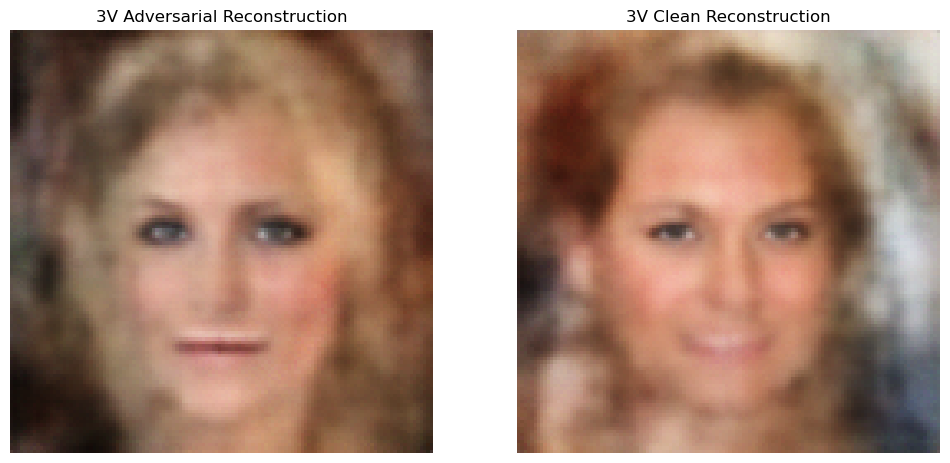

In [19]:
# Plot 3V images encoding vs decoding adv and non adv
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(adv_im_de_3V[0][0].permute(1, 2, 0))
plt.title('3V Adversarial Reconstruction')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(im_de_3V[0][0].permute(1, 2, 0))
plt.title('3V Clean Reconstruction')
plt.axis('off')
plt.show()

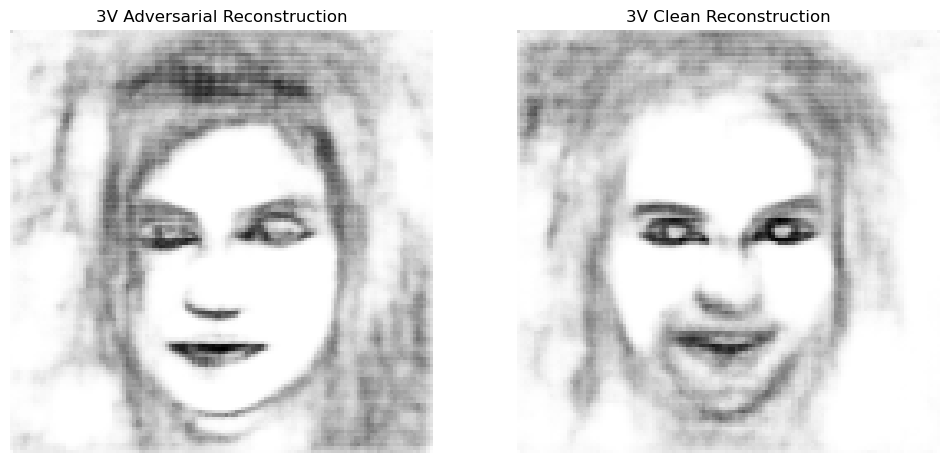

In [20]:
# Plot 3V images encoding vs decoding adv and non adv
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(adv_sk_de_3V[0][0].permute(1, 2, 0), cmap='gray')
plt.title('3V Adversarial Reconstruction')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sk_de_3V[0][0].permute(1, 2, 0), cmap='gray')
plt.title('3V Clean Reconstruction')
plt.axis('off')
plt.show()

## Attack Loss

In [21]:
clean_losses_im_1V = []
clean_losses_im_2V_IS, clean_losses_sk_2V_IS = [], []
clean_losses_im_2V_IL, clean_losses_la_2V_IL = [], []
clean_losses_im_3V, clean_losses_sk_3V, clean_losses_la_3V = [], [], []

adv_losses_im_1V = []
adv_losses_im_2V_IS, adv_losses_sk_2V_IS = [], []
adv_losses_im_2V_IL, adv_losses_la_2V_IL = [], []
adv_losses_im_3V, adv_losses_sk_3V, adv_losses_la_3V = [], [], []

In [22]:
for i in range(i_val):
    start, stop = i * 100, (i + 1) * 100

    batch_im = all_im[start:stop]
    adv_batch_im = all_adv_im[start:stop]

    batch_sk = all_sk[start:stop]
    adv_batch_sk = all_adv_sk[start:stop]

    batch_la = all_la[start:stop]
    adv_batch_la = all_la[start:stop]

    print(im_de_1V[i].shape, batch_im.shape)

    # 1V
    clean_losses_im_1V.append(recon_loss1(im_de_1V[i], batch_im).item())
    adv_losses_im_1V.append(recon_loss1(adv_im_de_1V[i], adv_batch_im).item())

    # 2V IS
    clean_losses_im_2V_IS.append(recon_loss1(im_de_2V_IS[i], batch_im).item())
    clean_losses_sk_2V_IS.append(recon_loss2(sk_de_2V_IS[i], batch_sk).item())

    adv_losses_im_2V_IS.append(recon_loss1(adv_im_de_2V_IS[i], adv_batch_im).item())
    adv_losses_sk_2V_IS.append(recon_loss2(adv_sk_de_2V_IS[i], adv_batch_sk).item())

    # 2V IL
    clean_losses_im_2V_IL.append(recon_loss1(im_de_2V_IL[i], batch_im).item())
    clean_losses_la_2V_IL.append(recon_loss3(la_de_2V_IL[i], batch_la).item())

    adv_losses_im_2V_IL.append(recon_loss1(adv_im_de_2V_IL[i], adv_batch_im).item())
    adv_losses_la_2V_IL.append(recon_loss3(adv_la_de_2V_IL[i], adv_batch_la).item())

    # 3V
    clean_losses_im_3V.append(recon_loss1(im_de_3V[i], batch_im).item())
    clean_losses_sk_3V.append(recon_loss2(sk_de_3V[i], batch_sk).item())
    clean_losses_la_3V.append(recon_loss3(la_de_3V[i], batch_la).item())

    adv_losses_im_3V.append(recon_loss1(adv_im_de_3V[i], adv_batch_im).item())
    adv_losses_sk_3V.append(recon_loss2(adv_sk_de_3V[i], adv_batch_sk).item())
    adv_losses_la_3V.append(recon_loss3(adv_la_de_3V[i], adv_batch_la).item())

torch.Size([100, 3, 128, 128]) torch.Size([100, 3, 128, 128])
torch.Size([100, 3, 128, 128]) torch.Size([100, 3, 128, 128])
torch.Size([100, 3, 128, 128]) torch.Size([100, 3, 128, 128])
torch.Size([100, 3, 128, 128]) torch.Size([100, 3, 128, 128])
torch.Size([100, 3, 128, 128]) torch.Size([100, 3, 128, 128])
torch.Size([100, 3, 128, 128]) torch.Size([100, 3, 128, 128])
torch.Size([100, 3, 128, 128]) torch.Size([100, 3, 128, 128])
torch.Size([100, 3, 128, 128]) torch.Size([100, 3, 128, 128])
torch.Size([100, 3, 128, 128]) torch.Size([100, 3, 128, 128])
torch.Size([100, 3, 128, 128]) torch.Size([100, 3, 128, 128])


In [23]:
# # Barchart of clean vs adversarial losses
# labels = ['1V', '2V IS', '2V IL', '3V']
# x = np.arange(len(labels))
# width = 0.35

# plt.figure(figsize=(10, 6))
# plt.bar(x - width/2, [np.mean(clean_losses_im_1V), np.mean(clean_losses_im_2V_IS), np.mean(clean_losses_im_2V_IL), np.mean(clean_losses_im_3V)], width, label='Clean', color='blue')
# plt.bar(x + width/2, [np.mean(adv_losses_im_1V), np.mean(   adv_losses_im_2V_IS), np.mean(adv_losses_im_2V_IL), np.mean(adv_losses_im_3V)], width, label='Adversarial', color='orange')
# plt.xticks(x, labels)
# plt.ylabel('Average Reconstruction Loss (MSE)')
# plt.title('Average Image Reconstruction Loss: Clean vs Adversarial')
# plt.legend()
# plt.show()  

In [24]:
models = ['1V', '2V-IS', '2V-IL', '3V']

clean_im_losses = [clean_losses_im_1V, clean_losses_im_2V_IS, clean_losses_im_2V_IL, clean_losses_im_3V]
adv_im_losses = [adv_losses_im_1V, adv_losses_im_2V_IS, adv_losses_im_2V_IL, adv_losses_im_3V]

clean_sk_losses = [None, clean_losses_sk_2V_IS, None, clean_losses_sk_3V]
adv_sk_losses = [None, adv_losses_sk_2V_IS, None, adv_losses_sk_3V]

clean_la_losses = [None, None, clean_losses_la_2V_IL, clean_losses_la_3V]
adv_la_losses = [None, None, adv_losses_la_2V_IL, adv_losses_la_3V]

In [25]:
# for i, x in enumerate(models):
#     r = pd.DataFrame({
#         'model': [x] * i_val,
#         'image_attack': [vta[0]] * i_val,
#         'sketch_attack': [vta[1]] * i_val,

#         'Clean_IM_Loss': clean_im_losses[i],
#         'FGSM_IM_Loss': adv_im_losses[i],
#         'Clean_SK_Loss': clean_sk_losses[i] if clean_sk_losses[i] is not None else [None] * i_val,
#         'FGSM_SK_Loss': adv_sk_losses[i] if adv_sk_losses[i] is not None else [None] * i_val,
#         'Clean_LA_Loss': clean_la_losses[i] if clean_la_losses[i] is not None else [None] * i_val,
#         'FGSM_LA_Loss': adv_la_losses[i] if adv_la_losses[i] is not None else [None] * i_val
#     })

#     results_file = 'Attack-B-Results.csv'
#     if os.path.exists(results_file):
#         r.to_csv(results_file, mode='a', header=False, index=False)
#     else:
#         r.to_csv(results_file, index=False)